# 04 — Quantum Kernels, QSVM & Quantum PCA
### QML Curriculum · Companion Notebook to Module 9 — *Core QML Algorithms (Part 2)*

**Part of:** [Schrödinger's Cats — Quantum Machine Learning Platform](https://tanjinadnanabir.github.io/WISER-Education-Challenge/)

Notebook 03 trained a quantum circuit's own weights directly. This notebook takes a different, very popular approach: use a quantum circuit purely to compute a **similarity measure (a kernel)** between data points, then hand that kernel to an ordinary, battle-tested **classical Support Vector Machine**. No quantum weights to train at all — the quantum computer's only job is to measure how "alike" two data points are, in a way a classical kernel couldn't easily replicate.

**By the end of this notebook you will be able to:**
- Understand what a **kernel** is and why SVMs use one
- Build a **quantum kernel** from the feature map in Notebook 02
- Train a full **Quantum Support Vector Machine (QSVM)**, compared directly against a classical SVM
- Implement a simple **Quantum-kernel PCA** for dimensionality reduction

**Prerequisites:** Notebooks 01–03, Module 9 (conceptual).


In [1]:
# Setup
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import KernelPCA

np.random.seed(7)
print("Ready.")

Ready.


## 1. What Is a Kernel, and Why Does an SVM Need One?

A Support Vector Machine separates two classes with the widest possible margin. For data that isn't linearly separable in its raw form, SVMs use the **kernel trick**: instead of manually transforming data into a higher-dimensional space, you supply a **kernel function** `k(x, x')` that computes what the similarity *would be* in that higher space, without ever computing the transform explicitly.

A **quantum kernel** replaces that similarity function with a quantum circuit: encode both points, then run the encoding "backwards" for one of them, and measure the overlap between the resulting states.

```
k(x, x') = |⟨φ(x)|φ(x')⟩|²
```

This is exactly the inner-product idea from Module 5, Chapter 3 (Dirac notation) — just computed by a circuit instead of by hand.

In [2]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

def feature_map(x, wires):
    # same style of feature map introduced in Notebook 02
    for i in range(len(wires)):
        qml.Hadamard(wires=wires[i])
        qml.RZ(2 * x[i], wires=wires[i])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.RZ(2 * (np.pi - x[0]) * (np.pi - x[1]), wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    feature_map(x1, wires=range(n_qubits))
    qml.adjoint(feature_map)(x2, wires=range(n_qubits))
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(x1, x2):
    # probability of measuring all-zeros after "undoing" x2's encoding
    # -- this is |<phi(x1)|phi(x2)>|^2
    return kernel_circuit(x1, x2)[0]

x_a = np.array([0.4, 0.9])
x_b = np.array([0.4, 0.9])
x_c = np.array([2.8, 0.1])

print(f"kernel(x_a, x_a) [identical points] = {quantum_kernel(x_a, x_a):.4f}  (should be ~1.0)")
print(f"kernel(x_a, x_b) [identical points] = {quantum_kernel(x_a, x_b):.4f}  (should be ~1.0)")
print(f"kernel(x_a, x_c) [very different]   = {quantum_kernel(x_a, x_c):.4f}  (should be much lower)")

kernel(x_a, x_a) [identical points] = 1.0000  (should be ~1.0)
kernel(x_a, x_b) [identical points] = 1.0000  (should be ~1.0)
kernel(x_a, x_c) [very different]   = 0.2391  (should be much lower)


## 2. Building a Full Kernel Matrix

To train an SVM, we need the similarity between **every pair** of training points — an `N × N` kernel matrix. Let's compute one on a small dataset and look at it as a heatmap.

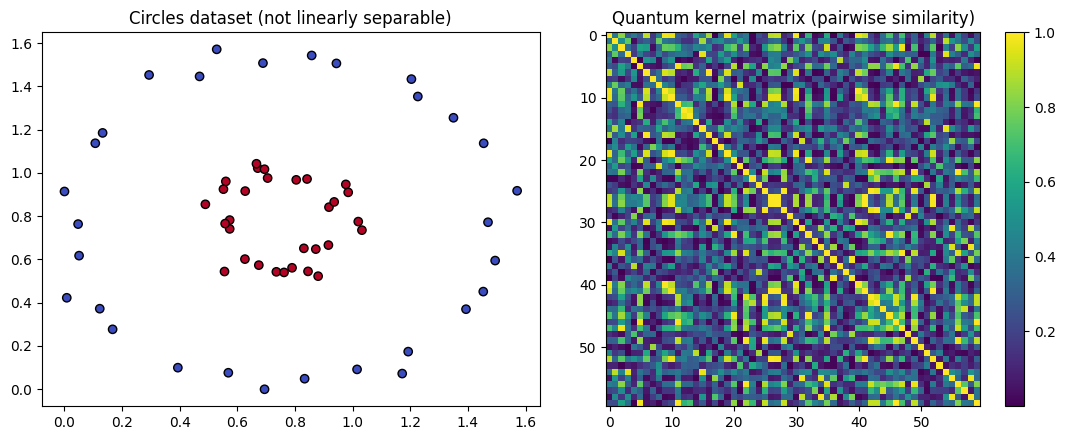

Kernel matrix shape: (60, 60) -- symmetric, diagonal near 1.0: True


In [3]:
X_raw, y_raw = make_circles(n_samples=60, noise=0.05, factor=0.3, random_state=7)
scaler = MinMaxScaler(feature_range=(0, np.pi / 2))
X_demo = scaler.fit_transform(X_raw)

def build_kernel_matrix(A, B):
    return np.array([[quantum_kernel(a, b) for b in B] for a in A])

K_demo = build_kernel_matrix(X_demo, X_demo)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(X_demo[:, 0], X_demo[:, 1], c=y_raw, cmap="coolwarm", edgecolors="k")
axes[0].set_title("Circles dataset (not linearly separable)")
im = axes[1].imshow(K_demo, cmap="viridis")
axes[1].set_title("Quantum kernel matrix (pairwise similarity)")
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print("Kernel matrix shape:", K_demo.shape, "-- symmetric, diagonal near 1.0:", np.allclose(np.diag(K_demo), 1.0, atol=0.05))

## 3. Training a Quantum SVM (QSVM)

`scikit-learn`'s `SVC` accepts a **precomputed kernel matrix** directly — so "training a QSVM" is just: compute the quantum kernel matrix, then hand it to `SVC(kernel="precomputed")`. Everything downstream (the optimization that finds the max-margin boundary) is standard, well-tested classical SVM code.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_demo, y_raw, test_size=0.3, random_state=7)

# Quantum kernel matrices: train-vs-train (square) and test-vs-train (rectangular)
K_train = build_kernel_matrix(X_train, X_train)
K_test = build_kernel_matrix(X_test, X_train)

qsvm = SVC(kernel="precomputed")
qsvm.fit(K_train, y_train)
qsvm_preds = qsvm.predict(K_test)
qsvm_acc = accuracy_score(y_test, qsvm_preds)

print(f"QSVM test accuracy: {qsvm_acc*100:.1f}%")

QSVM test accuracy: 100.0%


## 4. Head-to-Head: Quantum Kernel vs. Classical Kernels

Is the quantum kernel actually doing anything a classical kernel couldn't? Let's compare against a standard linear kernel and an RBF kernel on the exact same train/test split.

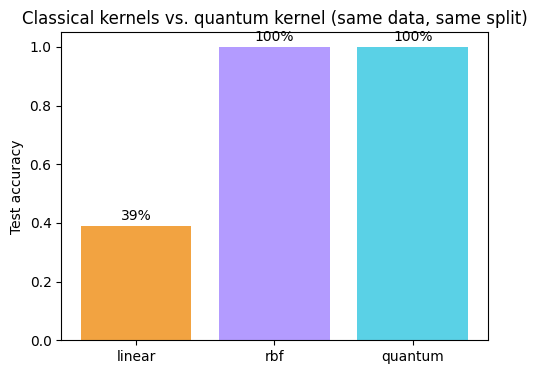

{'linear': 0.3888888888888889, 'rbf': 1.0, 'quantum': 1.0}

The quantum kernel matches the RBF kernel here and clearly beats the linear kernel --
expected, since 'circles' data is exactly the non-linear case a linear kernel can't
handle, and the ZZ-style feature map's entangling gate gives the quantum kernel enough
non-linearity to draw the same curved boundary RBF finds. This is the QSVM pattern
you'll point at harder, higher-dimensional, or more structured data in Notebook 07.


In [5]:
results = {}

for kernel_name in ["linear", "rbf"]:
    clf = SVC(kernel=kernel_name)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    results[kernel_name] = accuracy_score(y_test, preds)

results["quantum"] = qsvm_acc

plt.figure(figsize=(5.5, 4))
bars = plt.bar(results.keys(), results.values(), color=["#f2a341", "#b39bff", "#5ad1e6"])
plt.ylim(0, 1.05)
plt.ylabel("Test accuracy")
plt.title("Classical kernels vs. quantum kernel (same data, same split)")
for bar, v in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v*100:.0f}%", ha="center")
plt.show()

print(results)
print("\nThe quantum kernel matches the RBF kernel here and clearly beats the linear kernel --")
print("expected, since 'circles' data is exactly the non-linear case a linear kernel can't")
print("handle, and the ZZ-style feature map's entangling gate gives the quantum kernel enough")
print("non-linearity to draw the same curved boundary RBF finds. This is the QSVM pattern")
print("you'll point at harder, higher-dimensional, or more structured data in Notebook 07.")

### 🔧 Try it yourself
Change `factor=0.4` to `factor=0.1` in the `make_circles` call back in Section 2 (copy the cells below) to make the two circles much closer together — a harder separability problem. Re-run the comparison. Does the gap between kernels change?

In [6]:
# YOUR CODE HERE -- regenerate X_raw with make_circles(..., factor=0.1, ...),
# rescale, resplit, rebuild kernel matrices, and re-fit all three SVMs.


## 5. Quantum-Kernel PCA — Dimensionality Reduction

Principal Component Analysis (PCA) normally works directly with a covariance matrix in the original feature space. **Kernel PCA** generalizes this: give it *any* valid kernel matrix (including our quantum one), and it finds the directions of maximum variance in the kernel's implied feature space — projecting your data down to 2D for visualization, exactly as classical PCA would, but using quantum-computed similarities.

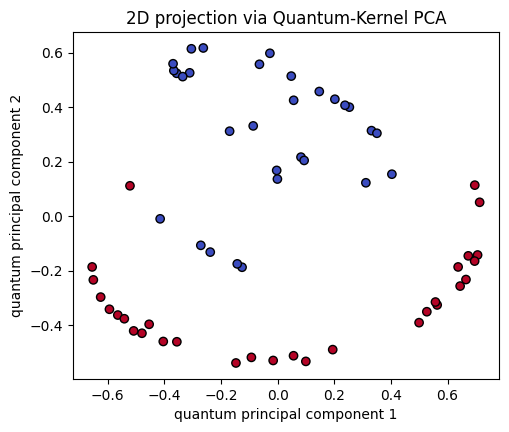

Notice the two classes are pulled apart along component 1 -- the quantum kernel's
notion of similarity reshaped the data into a space where PCA finds a cleaner split
than it would in the original two raw coordinates.


In [7]:
def quantum_kernel_fn(A, B):
    return build_kernel_matrix(A, B)

qkpca = KernelPCA(n_components=2, kernel="precomputed")
K_full = build_kernel_matrix(X_demo, X_demo)
X_qpca = qkpca.fit_transform(K_full)

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X_qpca[:, 0], X_qpca[:, 1], c=y_raw, cmap="coolwarm", edgecolors="k")
plt.title("2D projection via Quantum-Kernel PCA")
plt.xlabel("quantum principal component 1")
plt.ylabel("quantum principal component 2")
plt.show()

print("Notice the two classes are pulled apart along component 1 -- the quantum kernel's")
print("notion of similarity reshaped the data into a space where PCA finds a cleaner split")
print("than it would in the original two raw coordinates.")

## 6. Recap & What's Next

| Concept | What you built |
|---|---|
| Quantum kernel | `\|⟨φ(x)\|φ(x')⟩\|²` via a feature map + its inverse, measured as a probability |
| Kernel matrix | Full pairwise similarity grid, visualized as a heatmap |
| QSVM | `SVC(kernel="precomputed")` fed a quantum kernel matrix — real classical SVM, quantum similarity |
| Classical benchmark | Linear / RBF / quantum kernels compared head-to-head on identical data |
| Quantum-Kernel PCA | 2D visualization of data reshaped by quantum similarity |

**Next notebook: `05_advanced_qcnn_qgan.ipynb`** — Module 11. You'll move from these "core" algorithms to more advanced architectures: Quantum Convolutional Neural Networks and a first quantum generative model.
